In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
df=pd.read_csv('Electric_Production.csv')

In [52]:
df.describe()

,IPG2211A2N
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [53]:
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [59]:
df.sort_values(by='DATE', inplace=True)
df.set_index('DATE', inplace=True)

In [ ]:
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
import matplotlib.dates as mdates
import warnings


def run_stationarity_suite(series, label="Series"):
    """Run ADF, KPSS, and Phillips-Perron stationarity tests on a pandas Series.

    Parameters
    ----------
    series : pandas.Series
        Series to test. It must not contain NaN values.
    label : str, default "Series"
        Label used in the printed summary.

    Returns
    -------
    dict
        A dictionary containing test statistics, p-values, verdicts, and a
        summary DataFrame.

    Raises
    ------
    ValueError
        If the input series contains NaN values.
    """
    series = pd.Series(series)

    if series.isna().any():
        raise ValueError("series must not contain NaN values")

    series = series.astype(float)

    adf_stat, adf_pvalue, *_ = adfuller(series)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')
    pp_result = PhillipsPerron(series)

    summary = pd.DataFrame([
        {
            "Test": "ADF",
            "Statistic": adf_stat,
            "P-Value": adf_pvalue,
            "Verdict": "STATIONARY" if adf_pvalue < 0.05 else "NON-STATIONARY",
        },
        {
            "Test": "KPSS",
            "Statistic": kpss_stat,
            "P-Value": kpss_pvalue,
            "Verdict": "STATIONARY" if kpss_pvalue > 0.05 else "NON-STATIONARY",
        },
        {
            "Test": "Phillips-Perron",
            "Statistic": pp_result.stat,
            "P-Value": pp_result.pvalue,
            "Verdict": "STATIONARY" if pp_result.pvalue < 0.05 else "NON-STATIONARY",
        },
    ])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pd.to_datetime(df.loc[series.index, 'DATE']), series, label='Electric Production', color='blue')
    ax.set_xlabel('Date')
    ax.set_ylabel('Electric Production')
    ax.set_title(f'{label} Series')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    fig.autofmt_xdate(rotation=45)

    print(f"Stationarity summary for {label}")
    print(summary.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

    return {
        "label": label,
        "series": series,
        "summary": summary,
        "adf": {"statistic": adf_stat, "pvalue": adf_pvalue, "verdict": summary.loc[0, "Verdict"]},
        "kpss": {"statistic": kpss_stat, "pvalue": kpss_pvalue, "verdict": summary.loc[1, "Verdict"]},
        "pp": {"statistic": pp_result.stat, "pvalue": pp_result.pvalue, "verdict": summary.loc[2, "Verdict"]},
    }

Results for Original Series:
ADF TEST:
  P-Value: 0.000002
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000002
  Verdict: STATIONARY


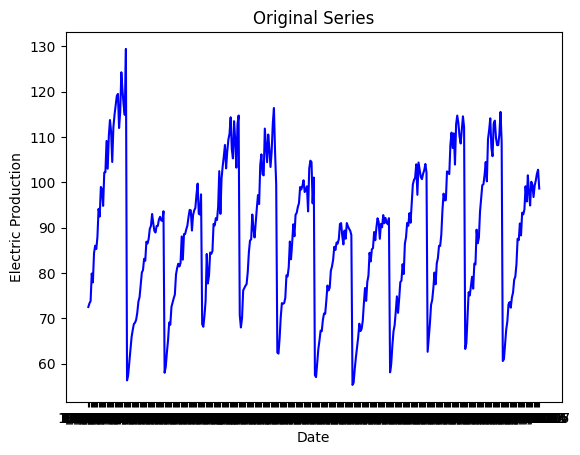

In [61]:
run_stationary_suites(df,'Original')

Results for 1st Difference Series:
ADF TEST:
  P-Value: 0.000000
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000000
  Verdict: STATIONARY


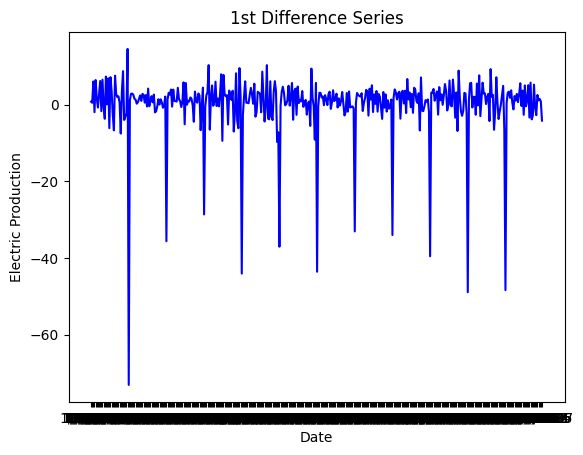

In [57]:
df1 = df.copy()
df1['IPG2211A2N'] = df1['IPG2211A2N'].diff()
df1 = df1.dropna(subset=['IPG2211A2N'])
run_stationary_suites(df1, '1st Difference')

c:\Users\Devank\Documents\Internship\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Results for Log Difference Series:
ADF TEST:
  P-Value: 0.000000
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000000
  Verdict: STATIONARY


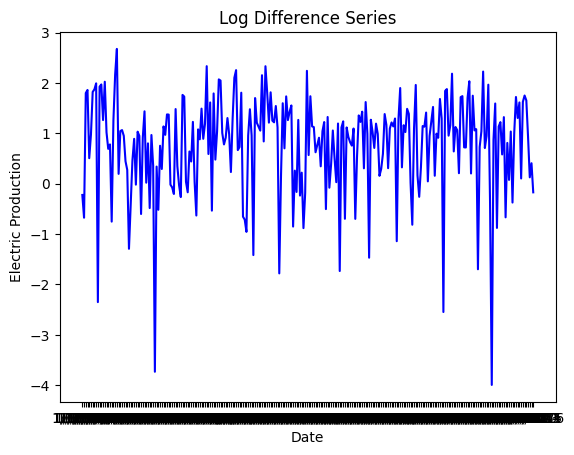

In [58]:
df2= df1.copy()
df2['IPG2211A2N'] = np.log(df2['IPG2211A2N'])
df2 = df2.dropna(subset=['IPG2211A2N'])
run_stationary_suites(df2, 'Log Difference')